
## Divergence‑Type Diffusion PINN

Solves the 1+1D equations
 
$\partial_t n + \partial_x q = 0,\qquad
 \partial_t(\lambda q) + \partial_x\alpha + \frac{1}{\sigma T}q = 0$.


 with hard initial‑condition enforcement and self‑adaptive collocation weights.

In [2]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt

from SA_PINN_DivType import PINN_DivType
import DivType_Functions
from DivType_Functions import n_func, sigmaT_func, lambda_func
from IC_DivType import IC_DivType
from Plotting_DivType import plot_results_divtype, plot_pde_residuals_divtype

DTYPE = torch.float32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == "cuda":
    torch.cuda.init()
    torch.rand(1, device=device)
print(f"Using device: {device}")

# Hyperparameters for network architecture and training schedule
Nl, Nn = 10, 70
t_end = 10.0
L = 50.0
adam_epochs = 25000
lr_net = 5e-3
lr_mask = 4e-2

# Sampling parameters and domain sampling
N_colloc = 20000
N_ic = 1000

# %% [collocation & IC]
def lhs_box(n, low, high, rng=np.random):
    low, high = np.asarray(low, float), np.asarray(high, float)
    D = low.size
    H = np.empty((n, D), float)
    for j in range(D):
        P = (rng.permutation(n) + rng.rand(n)) / n
        H[:, j] = low[j] + P * (high[j] - low[j])
    return H

X_colloc_np = lhs_box(N_colloc, low=[0.0, -L], high=[t_end, L]).astype(np.float32)

x_edges = np.linspace(-L, L, N_ic+1)
x_ic = (0.5 * (x_edges[:-1] + x_edges[1:])).reshape(-1, 1)
t_ic = np.zeros_like(x_ic)
X_ic = np.hstack((t_ic, x_ic))

X_ic_t = torch.tensor(X_ic, dtype=DTYPE, device=device)
q_ic_t, alpha_ic_t = IC_DivType(X_ic_t, L)

# Scales
with torch.no_grad():
    sq = q_ic_t.abs().max().clamp_min(1e-12).item()
    sA = alpha_ic_t.abs().max().clamp_min(1e-12).item()
print(f"Scales: sq={sq:.3e}, sA={sA:.3e}")

# %% [IC interpolation]
x_ic_torch = X_ic_t[:, 1:2].contiguous().view(-1)
x_sorted, idx_sort = torch.sort(x_ic_torch)
q_sorted     = q_ic_t.view(-1)[idx_sort]
alpha_sorted = alpha_ic_t.view(-1)[idx_sort]

@torch.no_grad()
def _lin_interp(xq, x, y):
    xq_flat = xq.view(-1).clamp(min=x[0], max=x[-1])
    idx_hi = torch.searchsorted(x, xq_flat, right=True).clamp(1, x.numel()-1)
    idx_lo = idx_hi - 1
    w = (xq_flat - x[idx_lo]) / (x[idx_hi] - x[idx_lo])
    return ((1-w)*y[idx_lo] + w*y[idx_hi]).view_as(xq)

def q_ic_func(x): return _lin_interp(x, x_sorted, q_sorted)
def alpha_ic_func(x): return _lin_interp(x, x_sorted, alpha_sorted)
def q_ic_func_scaled(x): return q_ic_func(x) / sq
def alpha_ic_func_scaled(x): return alpha_ic_func(x) / sA

# %% [collocation tensor]
X_colloc = torch.tensor(X_colloc_np, dtype=DTYPE, device=device)
x0_line = torch.linspace(-L, L, 500, dtype=DTYPE, device=device).unsqueeze(1)
X0 = torch.cat([torch.zeros_like(x0_line), x0_line], dim=1)
X_colloc = torch.cat([X_colloc, X0], dim=0)

# Self-adaptive collocation mask (learned weighting of PDE residual)
pde_logits = torch.nn.Parameter(torch.zeros((X_colloc.shape[0], 1), dtype=DTYPE, device=device))

def current_masks(detach: bool = False):
    pde = F.softplus(pde_logits)
    return pde.detach() if detach else pde

# %% [model]
lb = torch.tensor([0.0, -L], dtype=DTYPE, device=device)
ub = torch.tensor([t_end, L], dtype=DTYPE, device=device)
model = PINN_DivType(Nl, Nn, lb, ub).to(device).to(DTYPE)
model.q_ic_func     = q_ic_func_scaled
model.alpha_ic_func = alpha_ic_func_scaled
model.sq.copy_(torch.tensor(sq, dtype=DTYPE, device=device))
model.sA.copy_(torch.tensor(sA, dtype=DTYPE, device=device))

with torch.no_grad():
    n_ic_t = n_func(alpha_ic_t)          # compute n from alpha
    n_scale = n_ic_t.abs().max().item()
    alpha_scale = sA                      # already have from max(|alpha|)

model.n_scale      = n_scale
model.alpha_scale  = alpha_scale

print(f"Residual scales: n_scale={n_scale:.3e}, alpha_scale={alpha_scale:.3e}")

R = model.pde_residual(X_colloc[:500])

print("R1 rms =", torch.sqrt((R[:,0]**2).mean()).item())
print("R2 rms =", torch.sqrt((R[:,1]**2).mean()).item())

def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight, gain=1.0)
        if m.bias is not None: nn.init.zeros_(m.bias)
model.apply(init_weights)

DivType_Functions.USE_RTA_LAMBDA = False   # to use 12/n(α)
DivType_Functions.CONST_LAMBDA   = 500.0  # optional, only matters if flag is False

# Adam training
optimizer_theta = torch.optim.Adam(model.parameters(), lr=5e-3, betas=(0.9, 0.95))
scheduler = ReduceLROnPlateau(optimizer_theta, mode='min', factor=0.4, patience=700,
                              threshold=1e-4, min_lr=5e-5)   # lr_net/100
optimizer_mask = torch.optim.Adam([pde_logits], lr=4e-2, betas=(0.7, 0.85), maximize=True)

def train_adam(model, opt_theta, opt_mask, epochs, print_every):
    print("Adam pre‑training (SA-PINN, hard IC, self‑adaptive mask)...")
    best_loss, best_state = float('inf'), None
    history = []
    for epoch in range(1, epochs+1):
        opt_theta.zero_grad()
        opt_mask.zero_grad()

        R = model.pde_residual(X_colloc)          # (N, 2)
        R1, R2 = R[:, 0:1], R[:, 1:2]
        Rnorm = torch.sqrt(R1.pow(2) + R2.pow(2))  # pointwise norm

        mask = F.softplus(pde_logits)              # positive weights
        L_pde = (mask * Rnorm.pow(2)).mean()

        loss = L_pde
        if not torch.isfinite(loss):
            raise RuntimeError("NaN loss")

        loss.backward()
        opt_theta.step()
        opt_mask.step()          # mask updates every step (no delay needed)
        scheduler.step(loss.item())

        ltp = loss.item()
        history.append(ltp)
        if ltp < best_loss:
            best_loss = ltp
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % print_every == 0 or epoch == epochs:
            X_diag = X_colloc[:500].detach().clone().requires_grad_(True)
            R_check = model.pde_residual(X_diag)
            r1_rms = torch.sqrt(R_check[:,0].detach().pow(2).mean()).item()
            r2_rms = torch.sqrt(R_check[:,1].detach().pow(2).mean()).item()
            mask_mean = mask.detach().mean().item()
            print(f"Epoch {epoch}/{epochs} | loss={loss:.3e}, "
                  f"R1_rms={r1_rms:.3e}, R2_rms={r2_rms:.3e}, "
                  f"mask_mean={mask_mean:.2f}, lr={opt_theta.param_groups[0]['lr']:.3e}")
    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"Adam complete. Best loss = {best_loss:.3e}")
    return best_loss, history, best_state

start = time.time()
adam_loss, adam_hist, best_state = train_adam(model, optimizer_theta, optimizer_mask, adam_epochs, print_every=1000)
adam_end = time.time()

# %% [L‑BFGS fine‑tuning]
model.load_state_dict(best_state)
with torch.enable_grad():
    X_colloc.requires_grad_(True)
    R = model.pde_residual(X_colloc)
    init_lbfgs = torch.sqrt(R.pow(2).sum(dim=1)).pow(2).mean().item()
print(f"L‑BFGS init loss: {init_lbfgs:.3e}")
loss_scale = 1.0 / max(init_lbfgs, 1e-30)

optim_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=1000, max_eval=1000,
                                history_size=100, tolerance_grad=1e-10, tolerance_change=1e-12)
best_lbfgs = {"loss": float('inf'), "state": None}
inner_curve = []

def closure():
    optim_lbfgs.zero_grad(set_to_none=True)
    X = X_colloc.requires_grad_(True)
    R = model.pde_residual(X)
    raw = torch.sqrt(R.pow(2).sum(dim=1)).pow(2).mean()
    if not raw.isfinite(): raise RuntimeError("L‑BFGS NaN")
    loss = raw * loss_scale
    raw_f = raw.item()
    if raw_f < best_lbfgs["loss"]:
        best_lbfgs["loss"] = raw_f
        best_lbfgs["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    inner_curve.append(raw_f)
    loss.backward()
    return loss

lbfgs_start = time.time()
try:
    final_loss = optim_lbfgs.step(closure)
    final_raw = final_loss.item() / loss_scale
except RuntimeError:
    final_raw = float('nan')
if best_lbfgs["state"] is not None: model.load_state_dict(best_lbfgs["state"])
end_time = time.time()
print(f"L‑BFGS done. best={best_lbfgs['loss']:.3e}, calls={len(inner_curve)}")
print(f"Times: Adam {adam_end-start:.1f}s  L‑BFGS {end_time-lbfgs_start:.1f}s  total {end_time-start:.1f}s")

Using device: cuda
Scales: sq=1.100e+00, sA=1.034e+01
Residual scales: n_scale=1.200e+00, alpha_scale=1.034e+01
R1 rms = 0.3251165747642517
R2 rms = 9.223577499389648
Adam pre‑training (SA-PINN, hard IC, self‑adaptive mask)...
Epoch 1000/25000 | loss=1.134e+00, R1_rms=1.167e-02, R2_rms=1.610e-01, mask_mean=21.66, lr=2.000e-03
Epoch 2000/25000 | loss=9.705e-01, R1_rms=9.206e-03, R2_rms=7.361e-02, mask_mean=46.86, lr=8.000e-04
Epoch 3000/25000 | loss=2.379e-01, R1_rms=6.133e-03, R2_rms=4.170e-02, mask_mean=69.60, lr=8.000e-04
Epoch 4000/25000 | loss=2.560e-02, R1_rms=4.473e-03, R2_rms=1.861e-02, mask_mean=90.89, lr=3.200e-04
Epoch 5000/25000 | loss=8.584e-02, R1_rms=3.875e-03, R2_rms=2.666e-02, mask_mean=106.56, lr=3.200e-04
Epoch 6000/25000 | loss=1.192e-01, R1_rms=3.515e-03, R2_rms=2.595e-02, mask_mean=121.87, lr=3.200e-04
Epoch 7000/25000 | loss=1.030e-02, R1_rms=3.118e-03, R2_rms=7.690e-03, mask_mean=131.20, lr=1.280e-04
Epoch 8000/25000 | loss=1.845e-02, R1_rms=2.852e-03, R2_rms=6.4

### Evaluate & plot

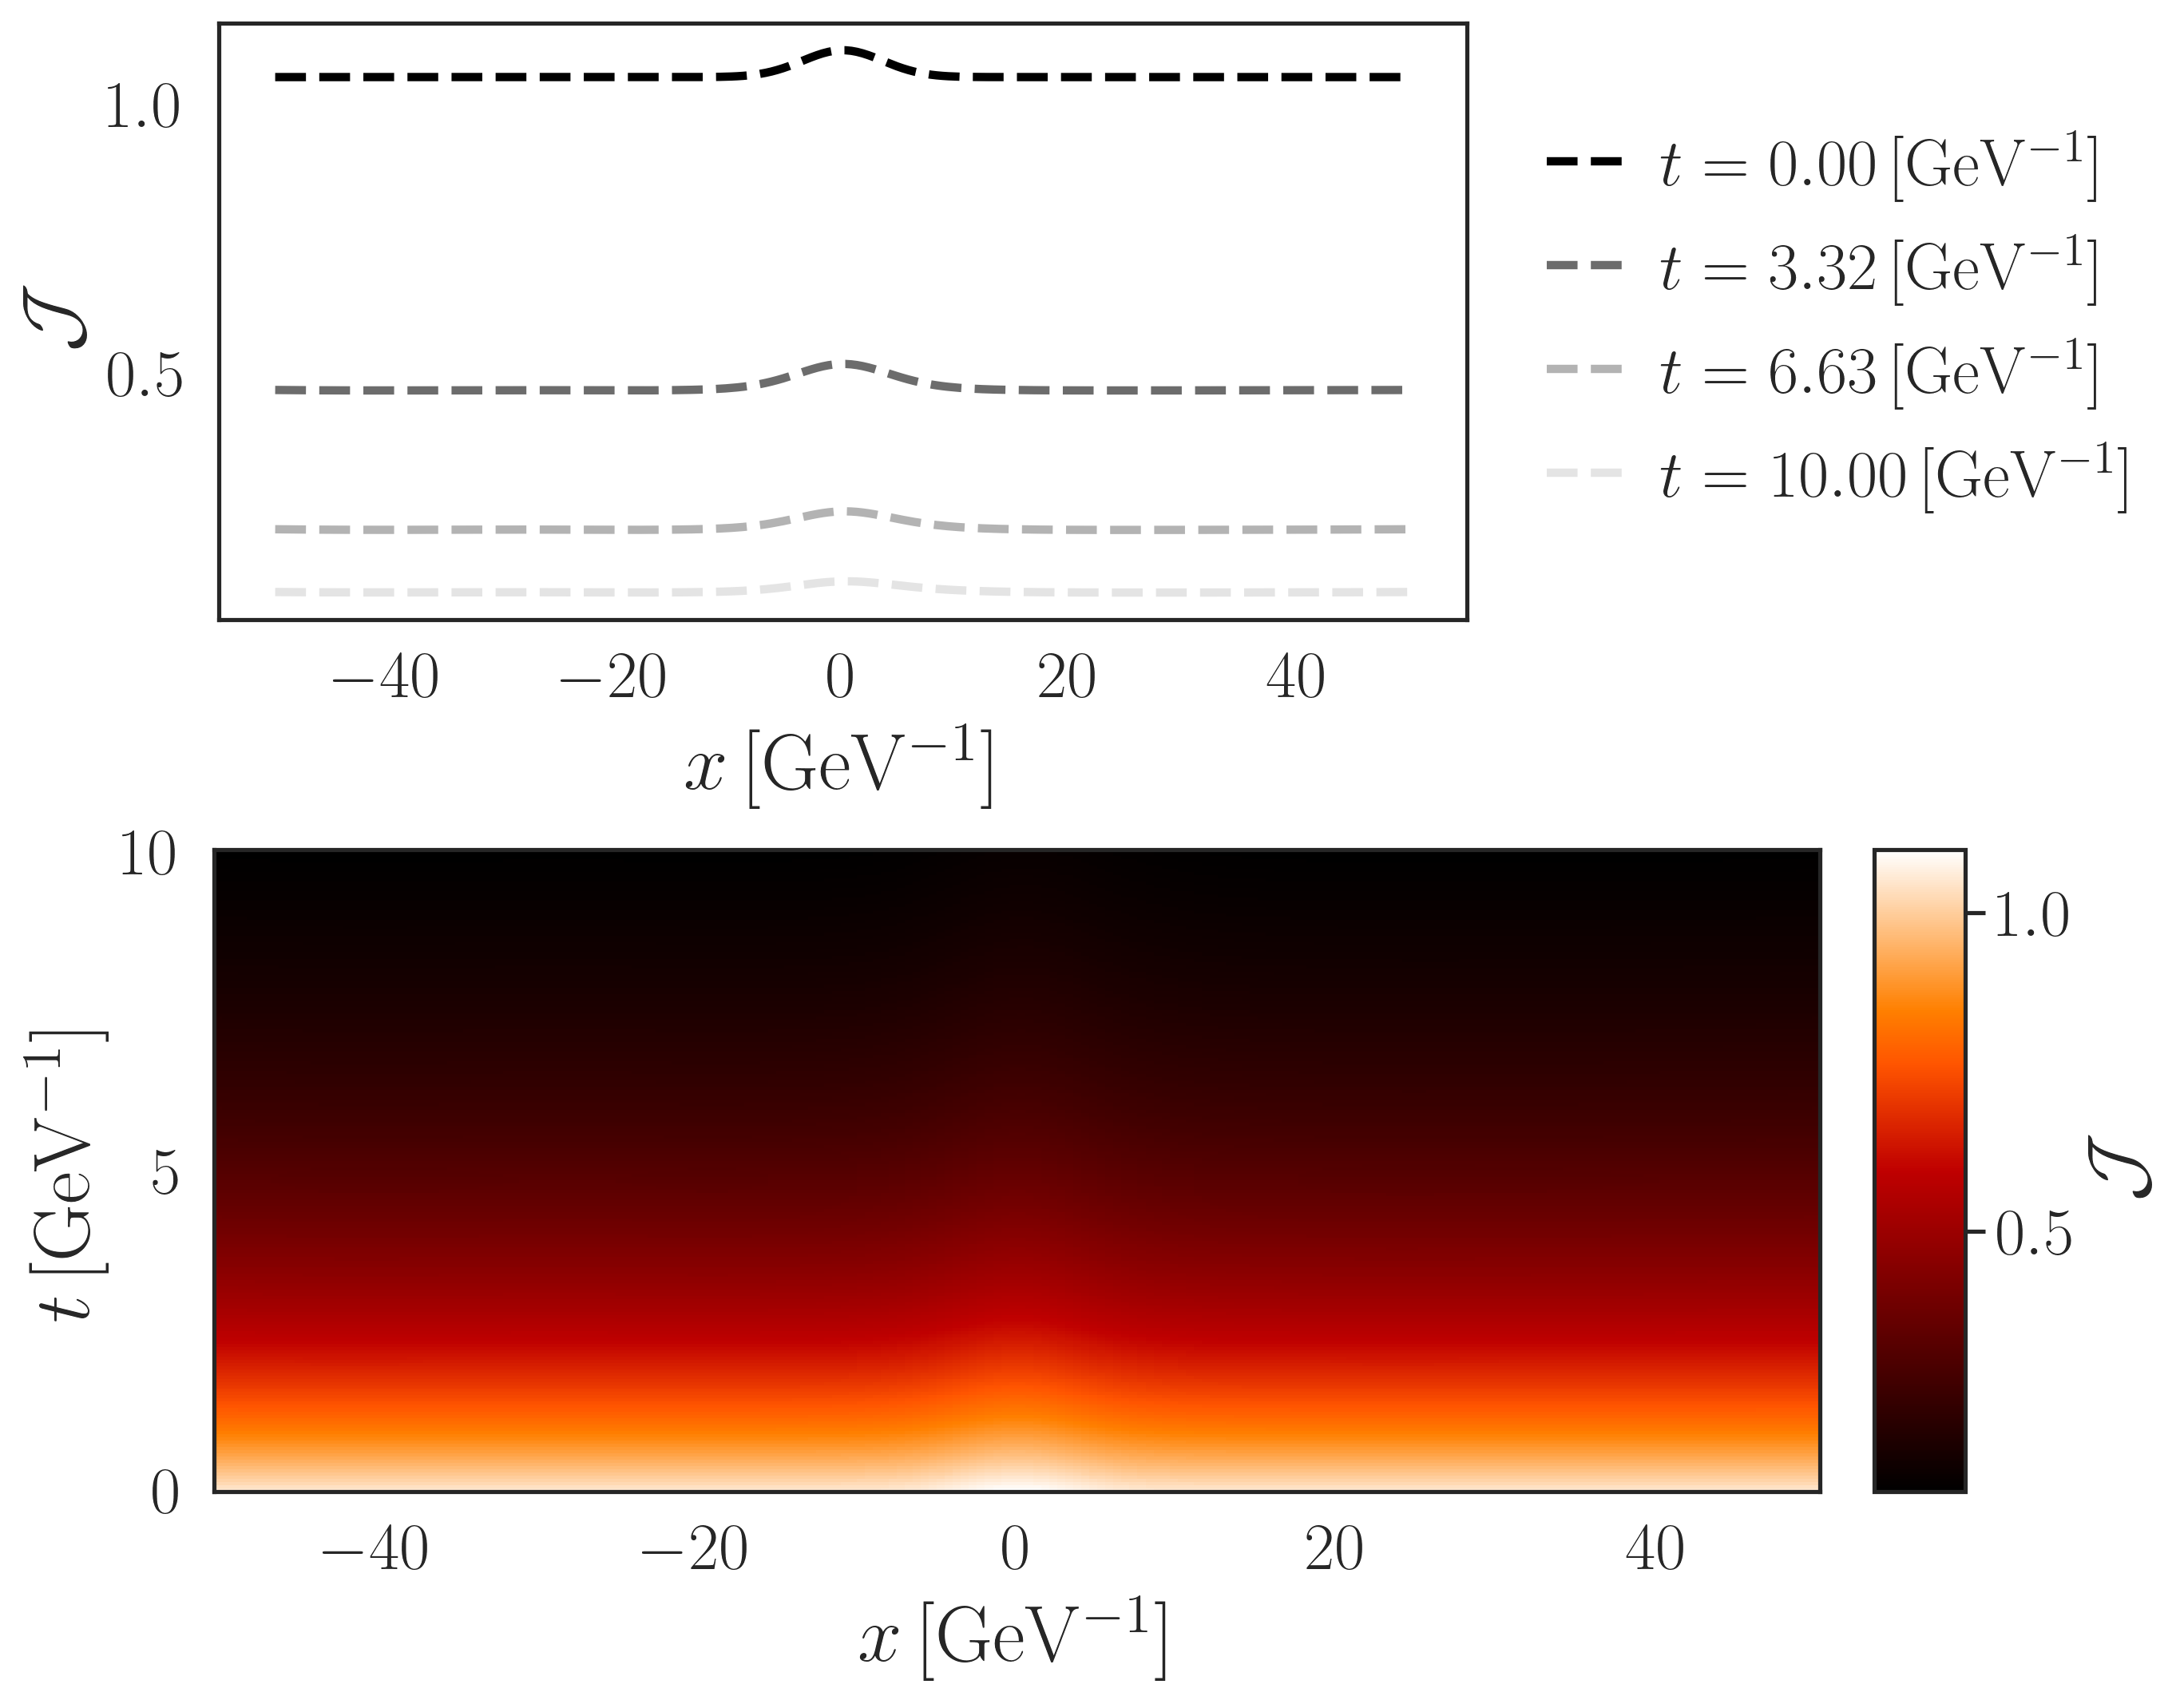

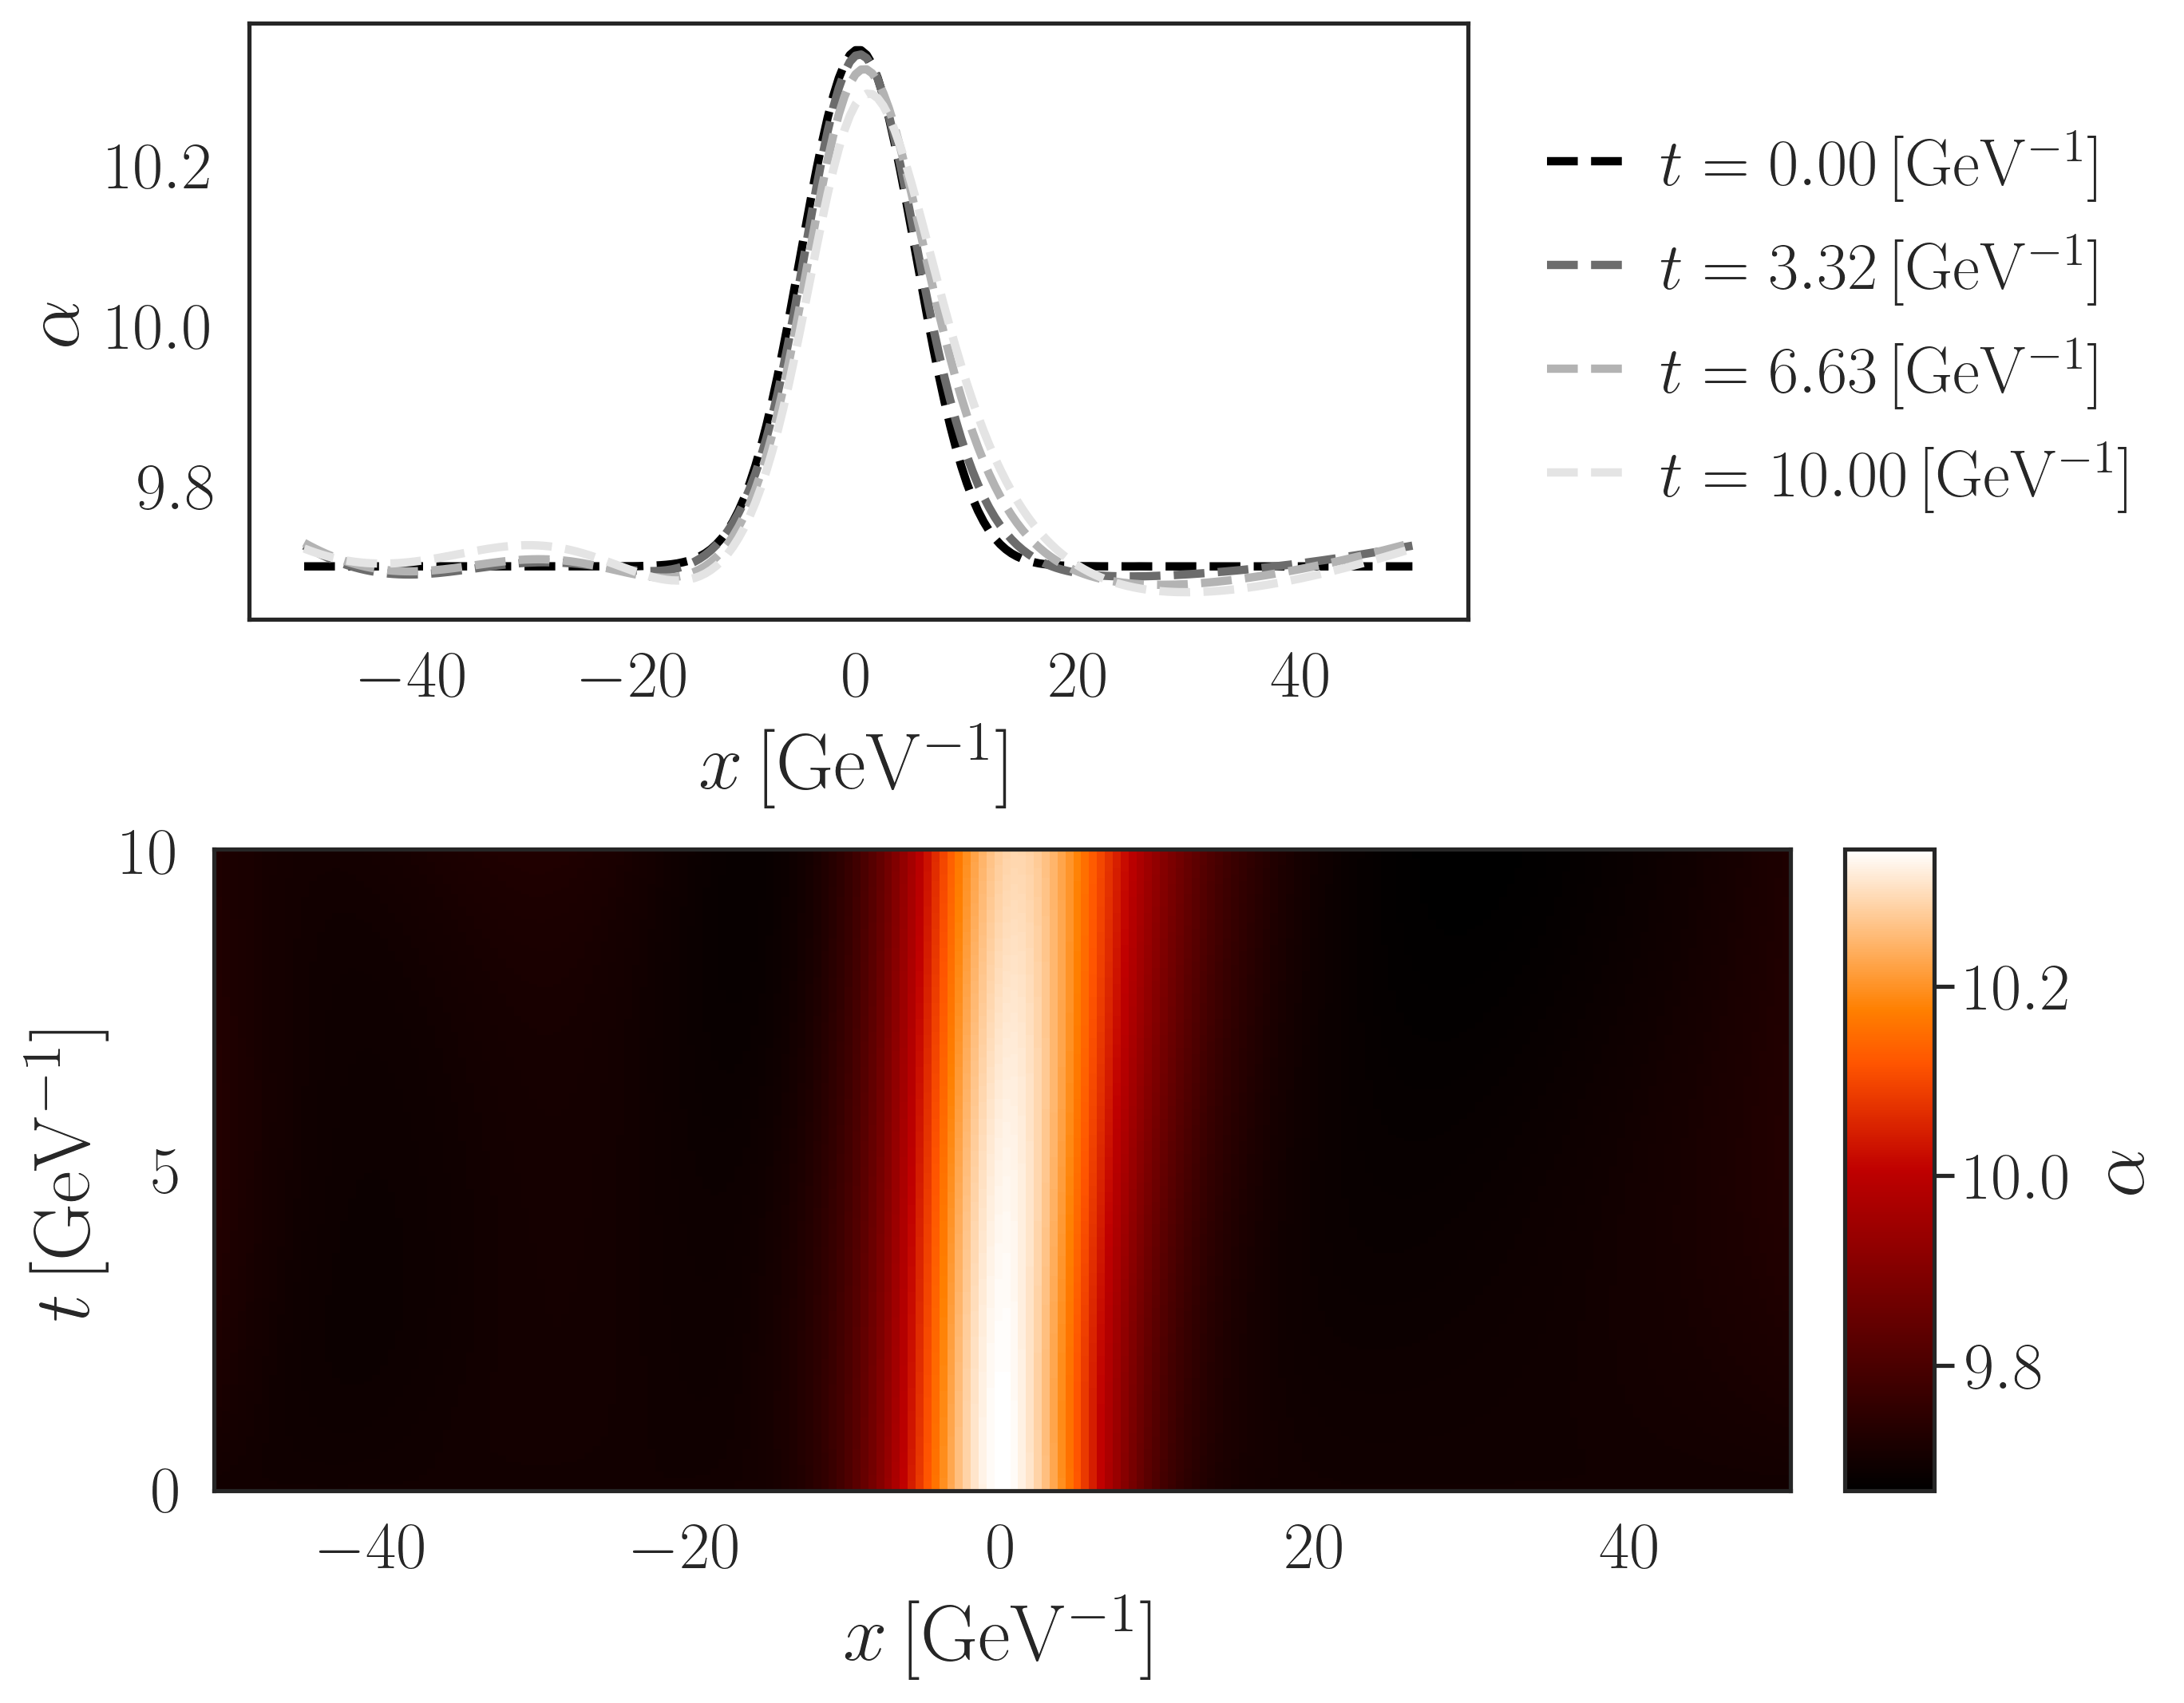

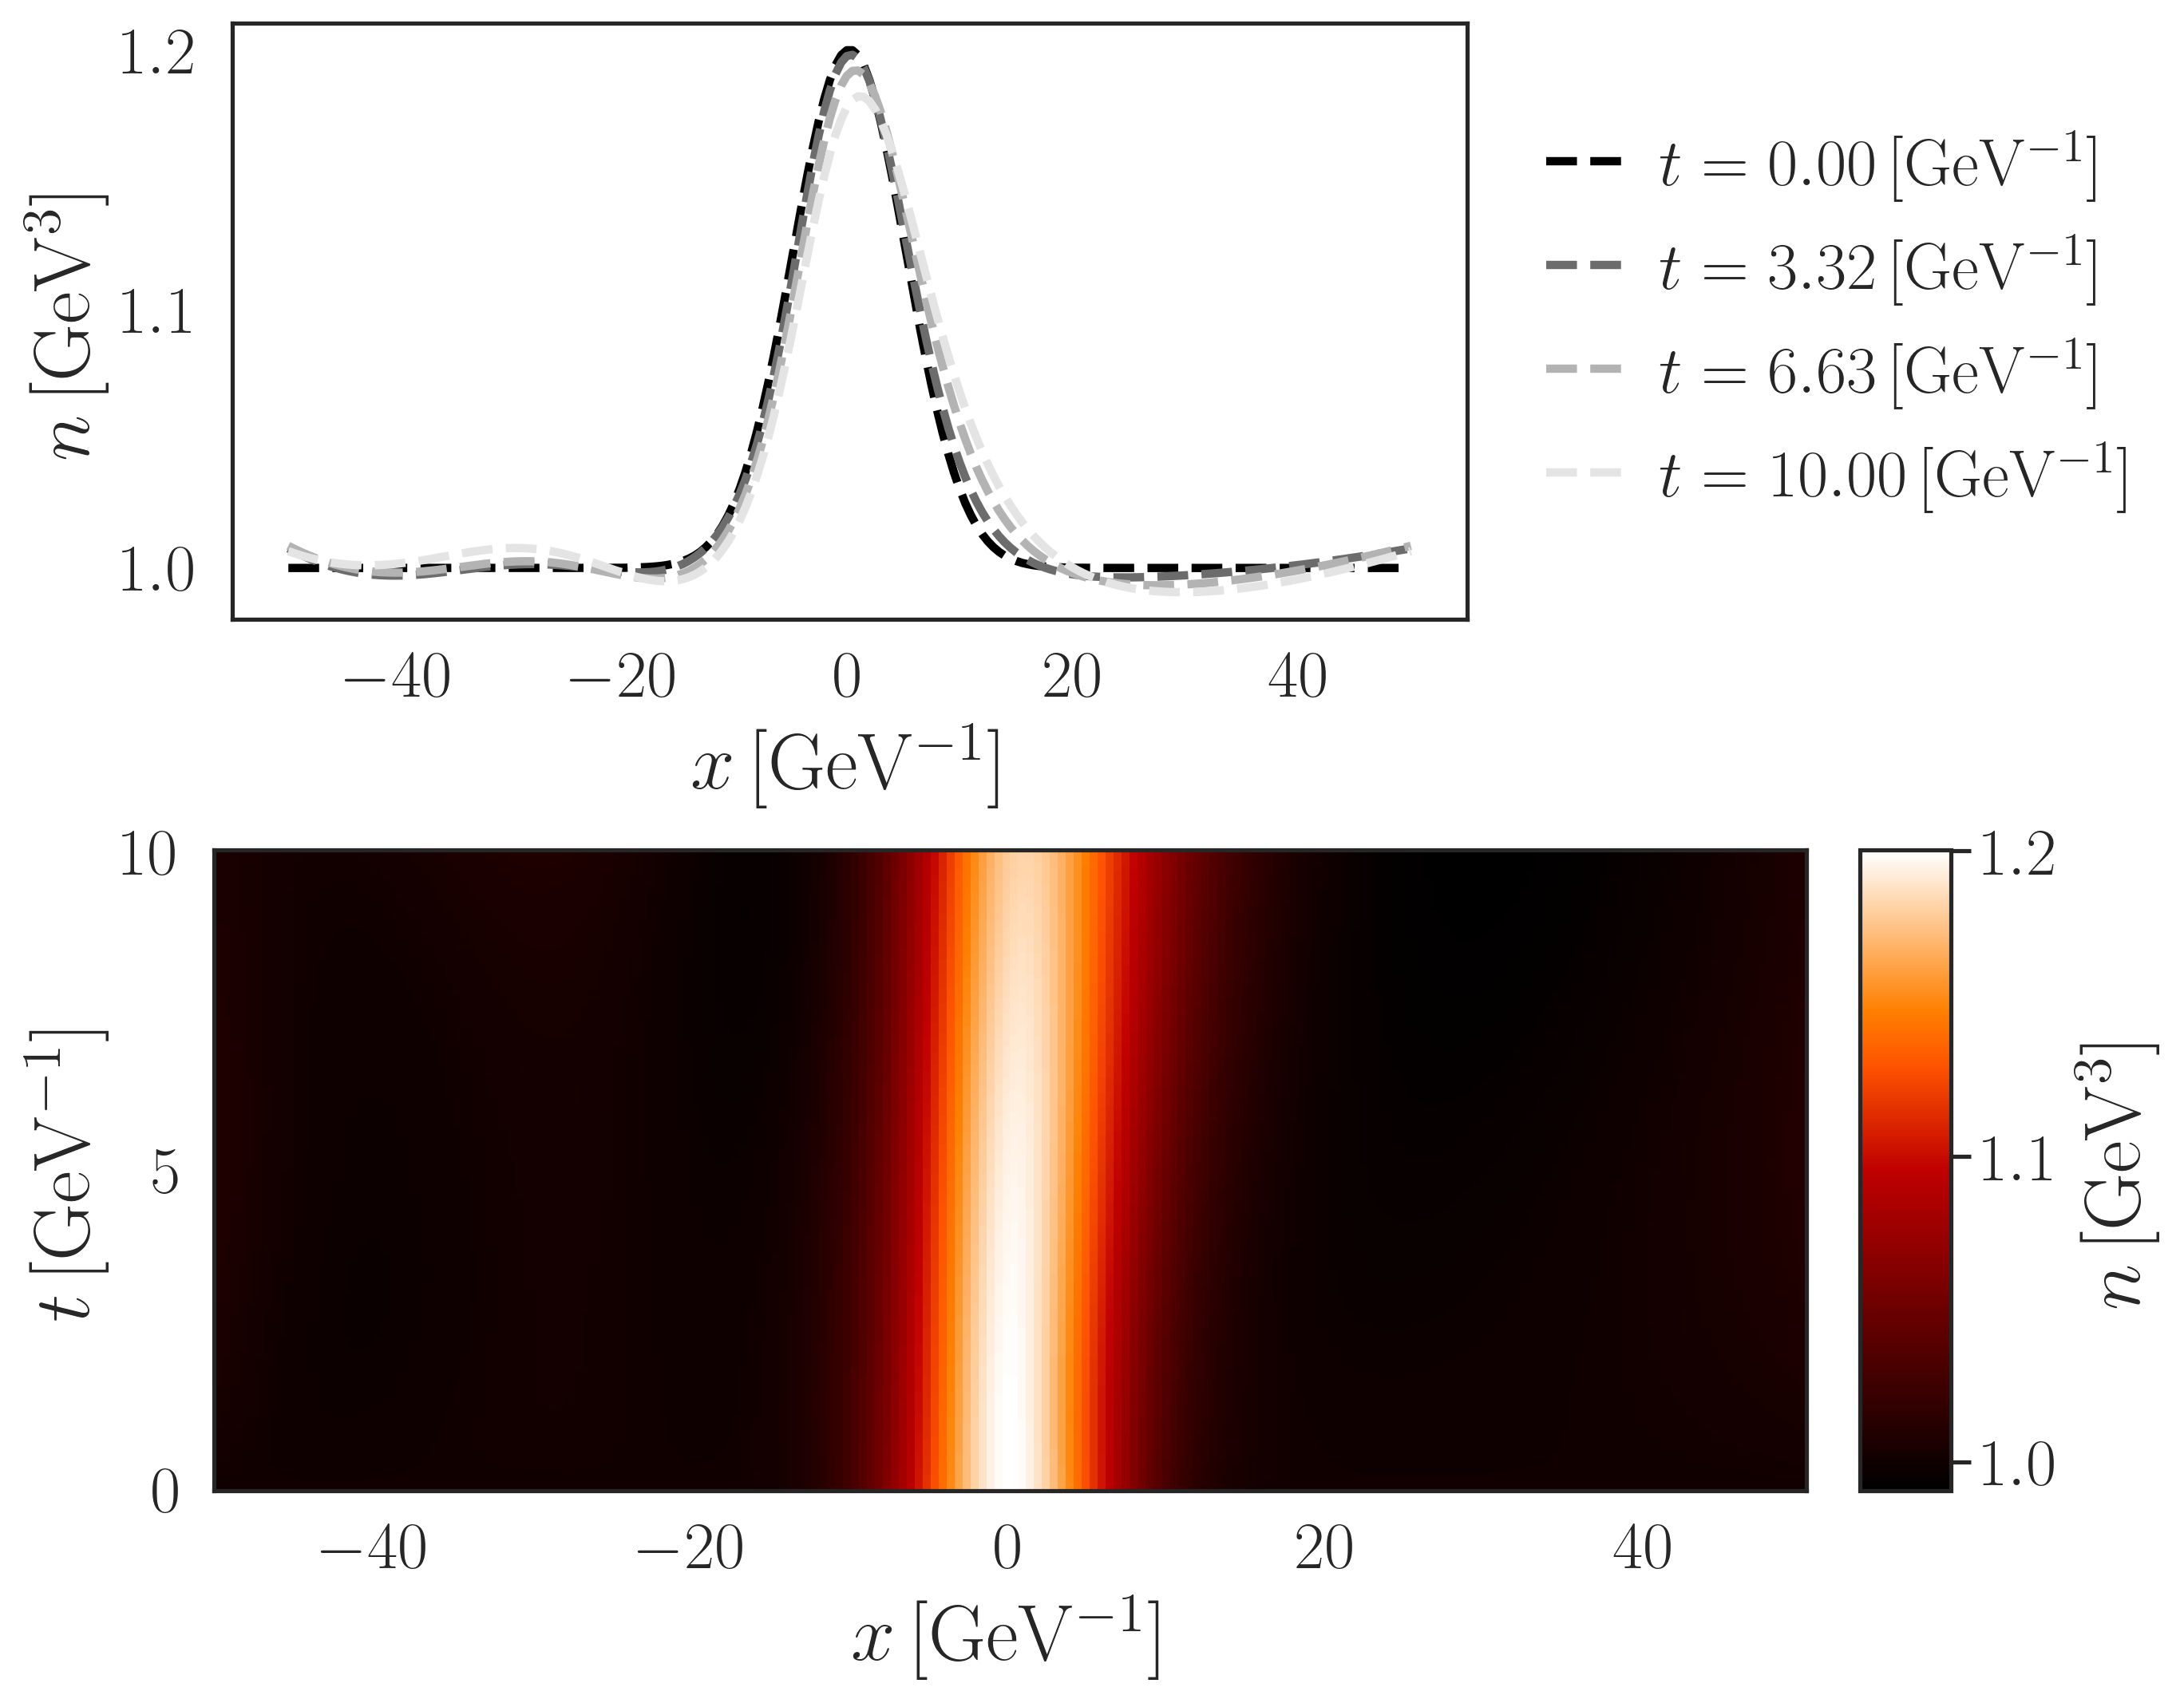

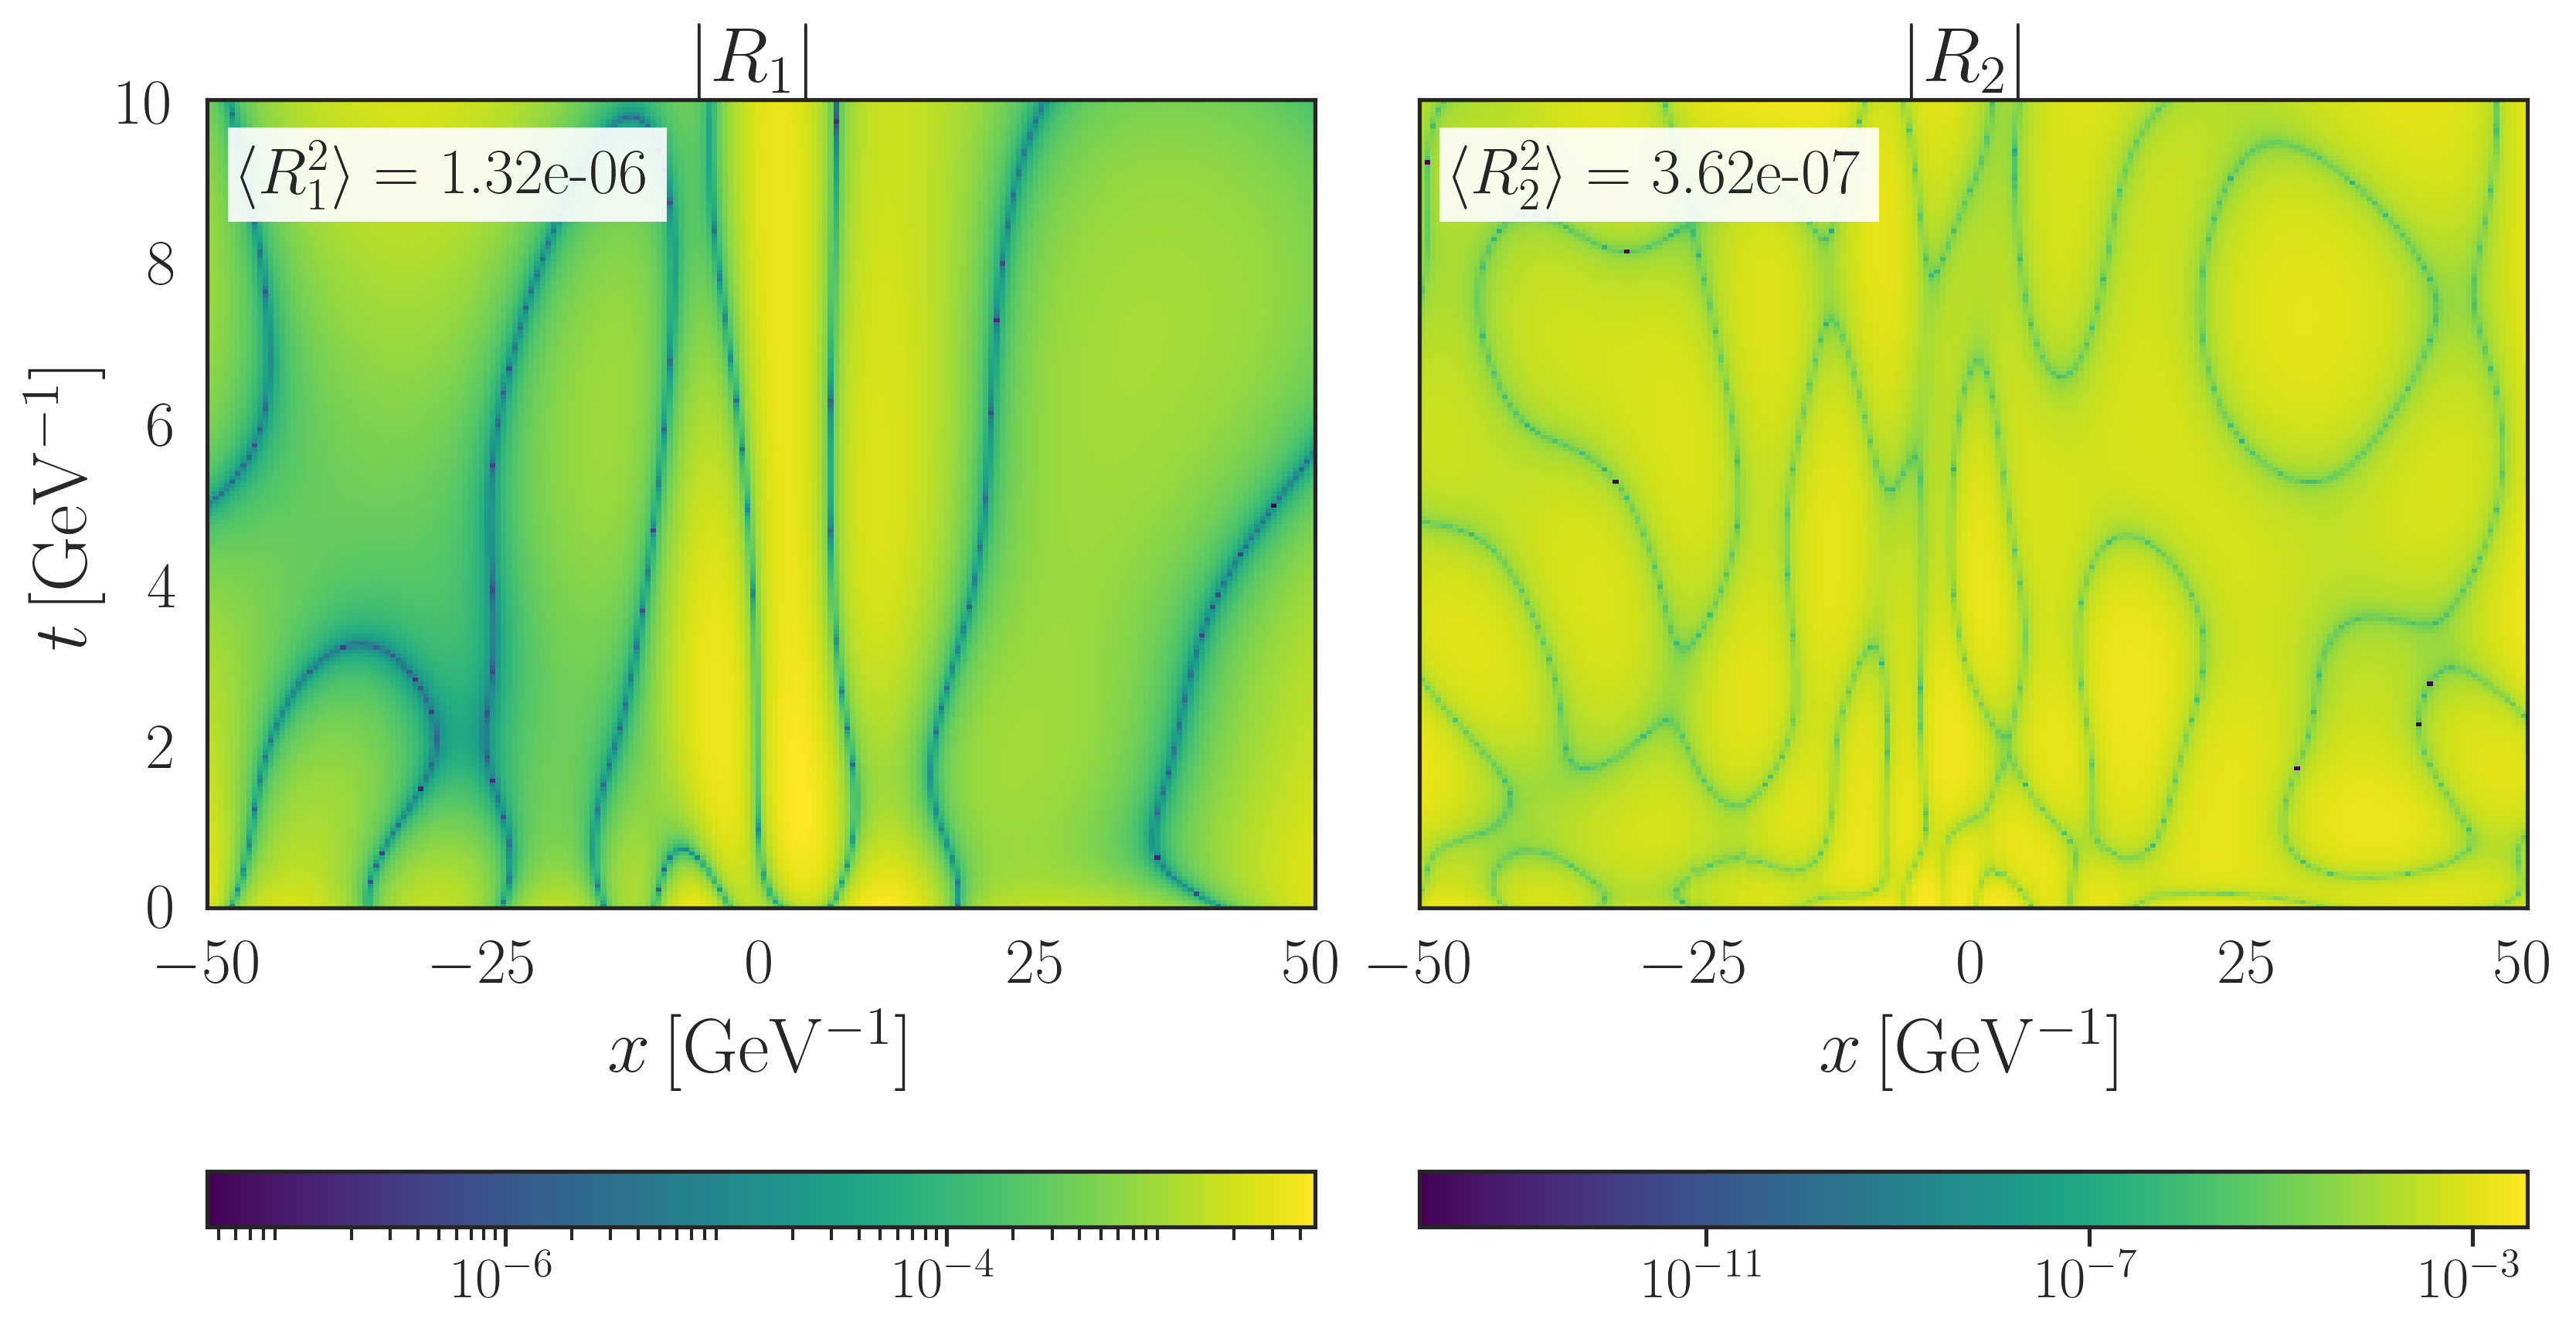

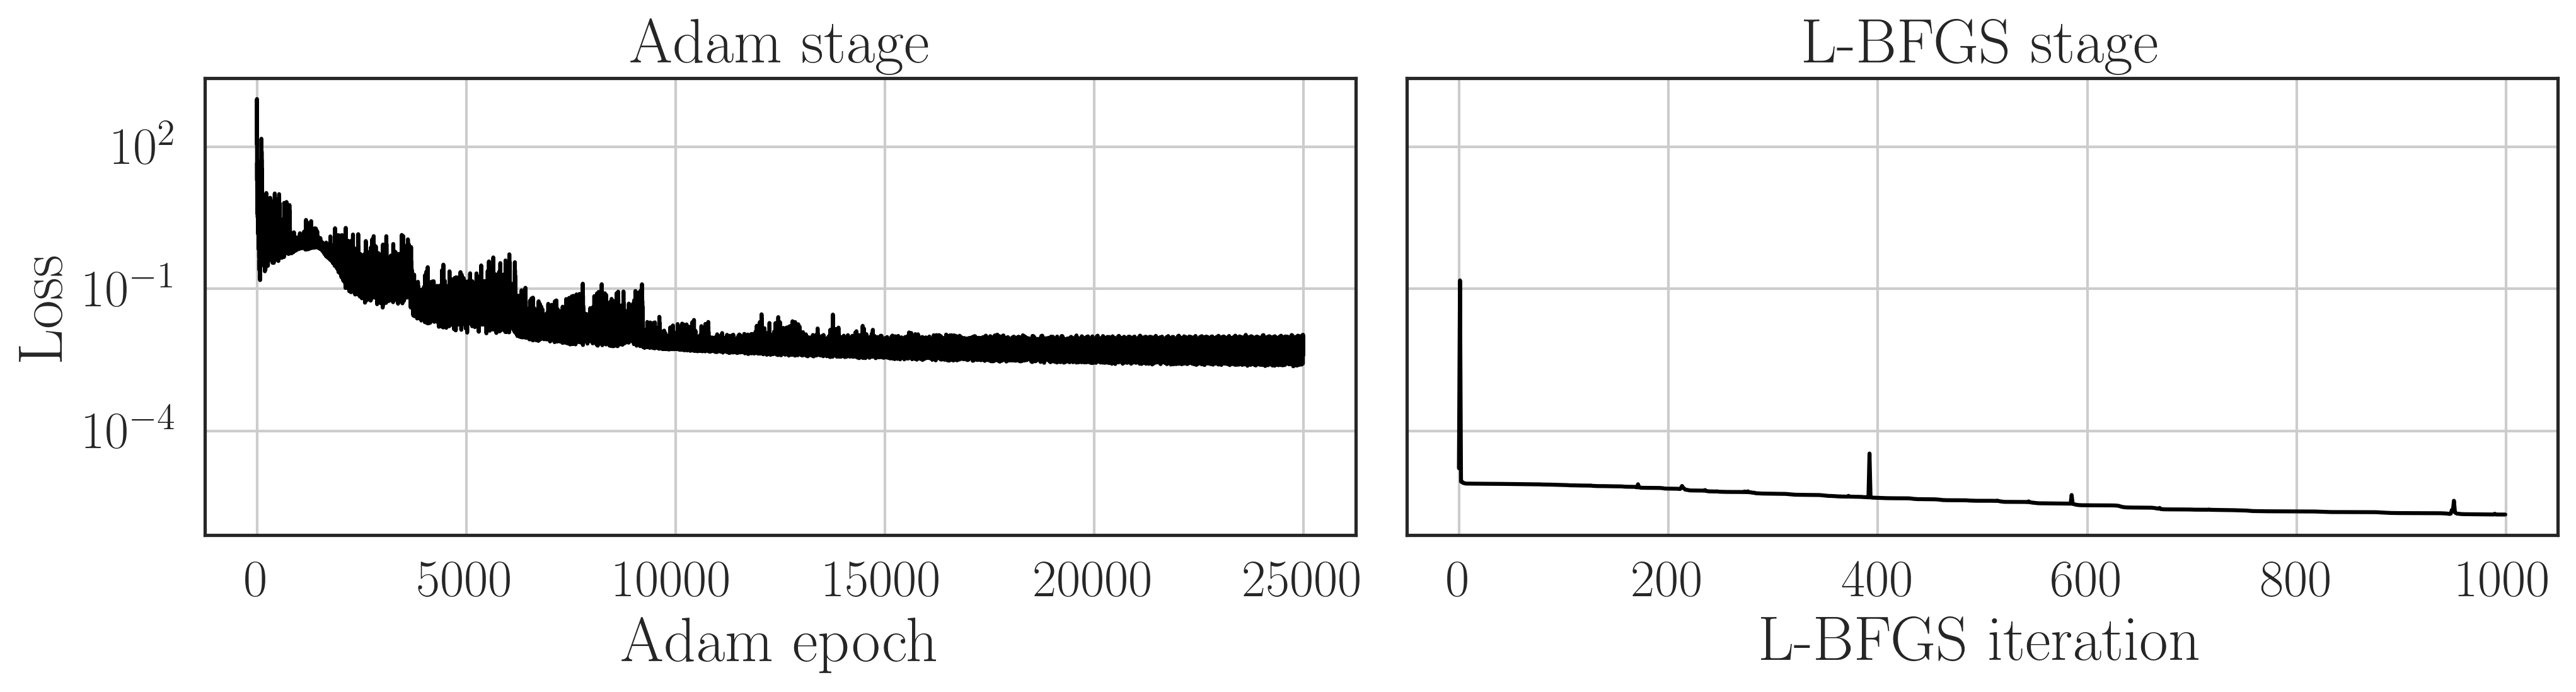

PINN evaluation data saved → ./pinn_runs/divtype_pinn_20260611_181021.npz


In [3]:
# %% [evaluate, plot, and save PINN fields]
from Plotting_DivType import (plot_results_divtype, plot_pde_residuals_divtype,
                              plot_loss_history)
import os, time, numpy as np, torch
from DivType_Functions import T_func, n_func          # ← only these are needed

# ---------- evaluation grid ----------
x_eval = np.linspace(-L, L, 200)
t_eval = np.linspace(0, t_end, 200)

# ---------- plot fields and PDE residuals ----------
plot_results_divtype(model, t_eval, x_eval)         # already uses n_func internally
plot_pde_residuals_divtype(model, t_eval, x_eval)

# ---------- loss history ----------
plot_loss_history(adam_hist, inner_curve)

# ---------- save the PINN predictions ----------
model.eval()
tt, xx = np.meshgrid(t_eval, x_eval, indexing='ij')
tx_tensor = torch.tensor(np.stack([tt.ravel(), xx.ravel()], axis=1),
                         dtype=DTYPE, device=device)

with torch.no_grad():
    pred = model(tx_tensor)
q_grid = pred[:, 0].view(len(t_eval), len(x_eval)).cpu().numpy()
alpha_grid = pred[:, 1].view(len(t_eval), len(x_eval)).cpu().numpy()

# Compute n using the new equation of state
alpha_t = torch.tensor(alpha_grid, dtype=DTYPE, device=device)
n_grid = n_func(alpha_t).cpu().numpy()

run_id = time.strftime("%Y%m%d_%H%M%S")
save_dir = "./pinn_runs"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, f"divtype_pinn_{run_id}.npz")
np.savez_compressed(save_path,
                    t_eval=t_eval, x_eval=x_eval,
                    q=q_grid, alpha=alpha_grid, n=n_grid)
torch.save(model.state_dict(), f"./pinn_runs/divtype_model_{run_id}.pt")
print(f"PINN evaluation data saved → {save_path}")